In [ ]:
%load_ext rpy2.ipython

In [ ]:
%%R
install.packages("mclust")
library(mclust)

data("banknote")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/mclust_6.1.1.tar.gz'
Content type 'application/x-gzip' length 2753243 bytes (2.6 MB)
downloaded 2.6 MB


The downloaded source packages are in
	‘/tmp/RtmpetLnLl/downloaded_packages’
                   __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.


In [ ]:
notas = %R banknote

notas.columns = ["Status", "Comprimento", "Esquerda", "Direita",
                 "Abaixo", "Acima", "Diagonal"]
notas.head()

,Status,Comprimento,Esquerda,Direita,Abaixo,Acima,Diagonal
1,genuine,214.8,131.0,131.1,9.0,9.7,141.0
2,genuine,214.6,129.7,129.7,8.1,9.5,141.7
3,genuine,214.8,129.7,129.7,8.7,9.6,142.2
4,genuine,214.8,129.7,129.6,7.5,10.4,142.0
5,genuine,215.0,129.6,129.7,10.4,7.7,141.8


In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
notas.shape

(200, 7)

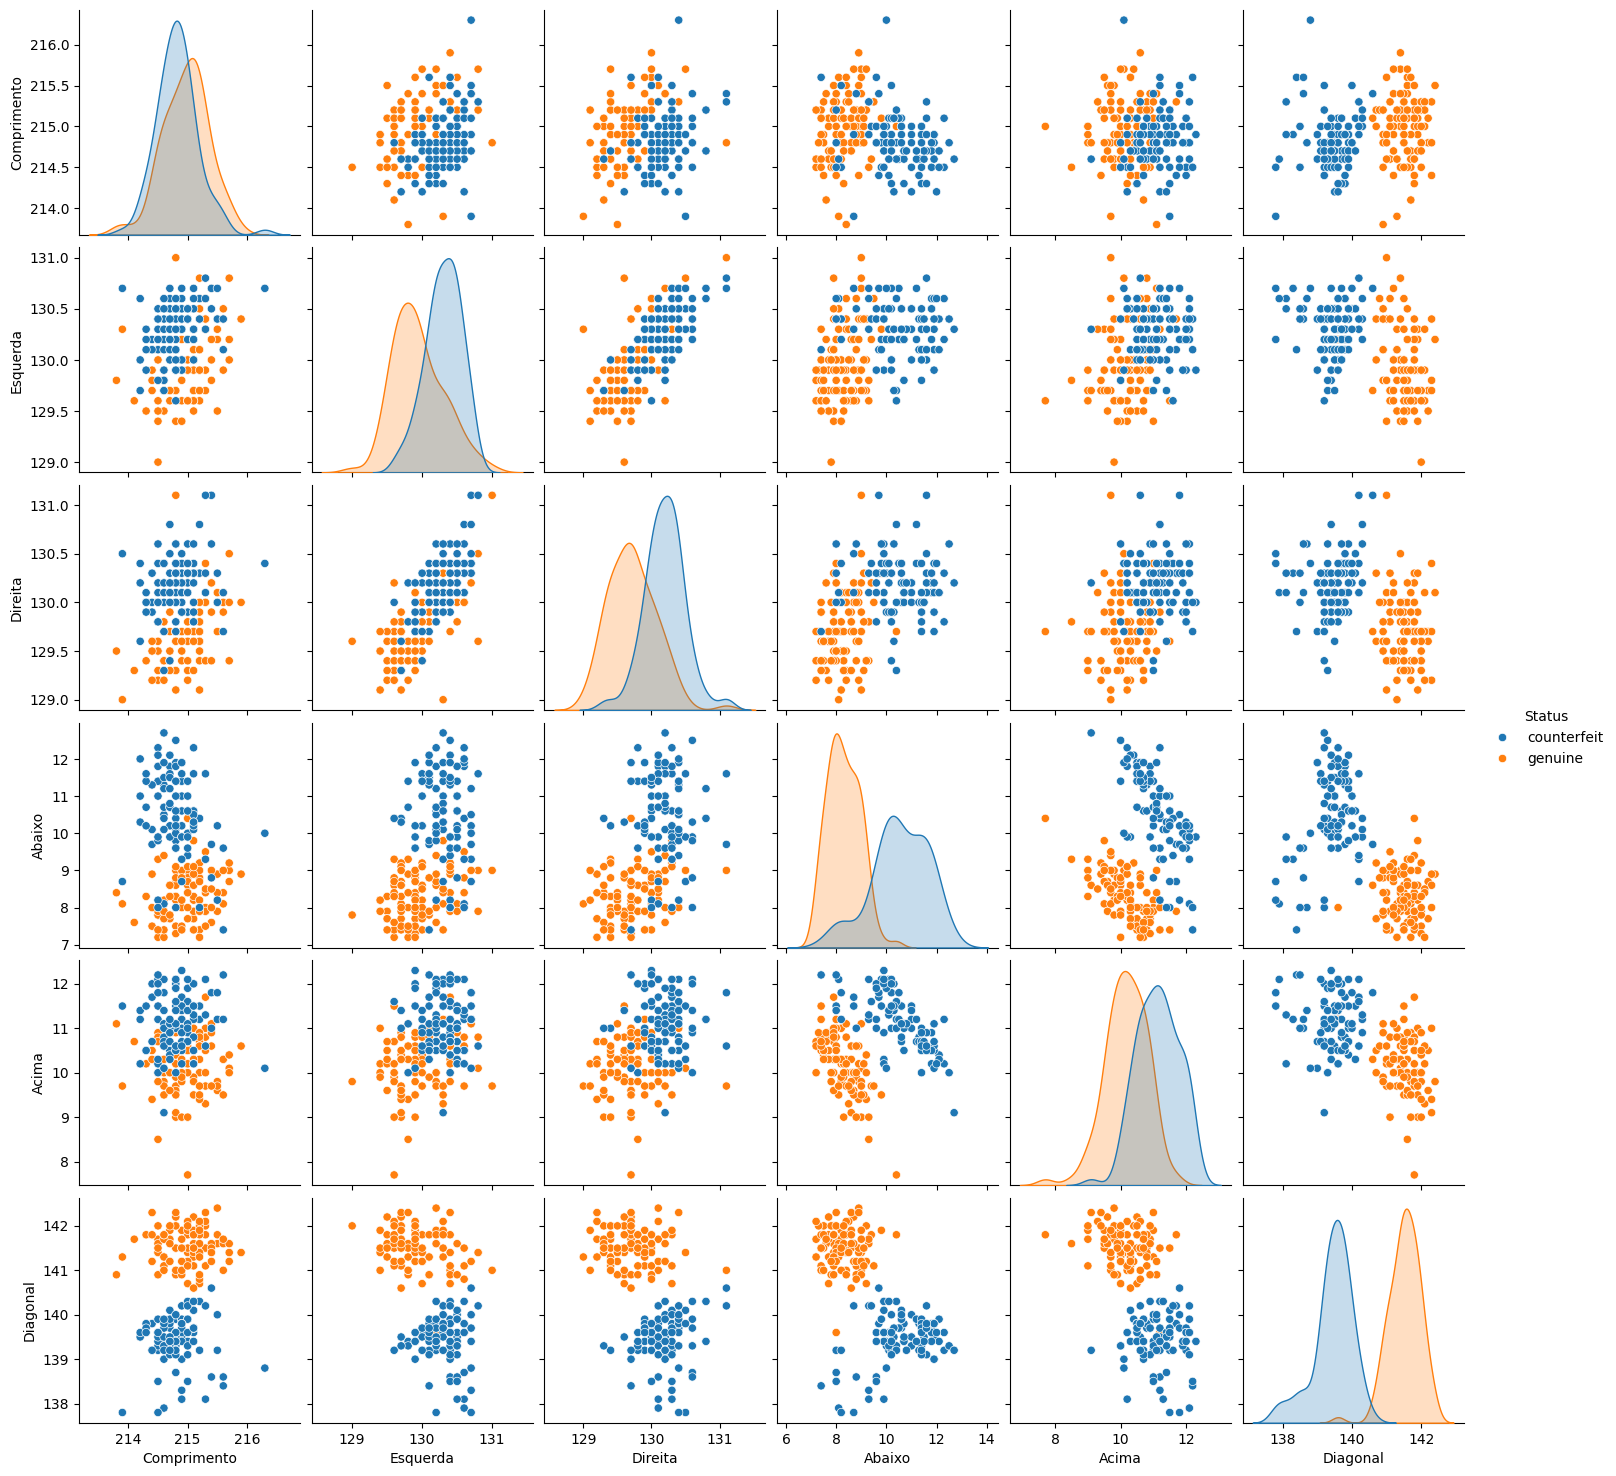

In [ ]:
sns.pairplot(notas, hue="Status")

In [ ]:
y = (notas['Status'] == 'genuine')
x = notas.drop('Status', axis=1)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x,y)

In [ ]:
scaler = StandardScaler()
scaler = scaler.fit(X_train)

X_norm_train = scaler.transform(X_train)
X_norm_test = scaler.transform(X_test)

In [ ]:
ridge = LogisticRegression(penalty="l2")
ridge.fit(X_norm_train, y_train)
y_pred = ridge.predict(X_norm_test)

In [ ]:
ridge.coef_

array([[ 0.28896815, -0.11073782, -0.5146941 , -1.9809481 , -1.38166979,
         1.970682  ]])

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_curve, recall_score, precision_score, f1_score

In [ ]:
confusion_matrix(y_test, y_pred)

array([[28,  0],
       [ 0, 22]])

In [ ]:
lasso = LogisticRegression(penalty="l1", solver="saga")
lasso.fit(X_norm_train, y_train)
y_pred = lasso.predict(X_norm_test)

In [ ]:
lasso.coef_

array([[ 0.        ,  0.        , -0.12028777, -2.7406384 , -1.4970623 ,
         2.51324785]])